In [1]:
# ==============================================================================
# CELDA 1: CONFIGURACIÓN DEL ENTORNO, DIRECTORIO Y PIVOT DE CARACTERÍSTICAS
# ==============================================================================
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Forzar al entorno de Jupyter a trabajar desde la raíz del proyecto
raiz_proyecto = Path().resolve().parent
os.chdir(raiz_proyecto)

# Agregar la raíz al sys.path para las importaciones formales de 'src/'
if str(raiz_proyecto) not in sys.path:
    sys.path.insert(0, str(raiz_proyecto))

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print("=== 1. PREPROCESAMIENTO Y AGREGACIÓN ESTATAL ===")

# Cargar el dataset crudo
df = pd.read_csv('data/raw/incidencia_delictiva.csv', encoding='latin-1')

# Generar la tabla pivote para consolidar el perfil delictivo por entidad federativa
tabla_pivot = (
    df.groupby(['entidad_federativa', 'tipo_delito'])['incidencia_delictiva']
    .sum()
    .reset_index()
    .pivot(index='entidad_federativa', columns='tipo_delito', values='incidencia_delictiva')
    .fillna(0)
)

print(f"Tabla pivot construida: {tabla_pivot.shape[0]} entidades × {tabla_pivot.shape[1]} tipos de delito")

=== 1. PREPROCESAMIENTO Y AGREGACIÓN ESTATAL ===
Tabla pivot construida: 32 entidades × 40 tipos de delito


In [2]:
# ==============================================================================
# CELDA 2: ESCALAMIENTO ESTÁNDAR Y REDUCCIÓN DE DIMENSIONALIDAD (PCA)
# ==============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Escalamiento obligatorio para evitar distorsiones por magnitud en K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tabla_pivot)

# Reducción dimensional con PCA para facilitar la visualización geométrica
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

var_explicada = pca.explained_variance_ratio_.sum()
print(f"Varianza explicada acumulada por los 2 primeros componentes (PC): {var_explicada:.2%}")
print(f"  - PC1 explica: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - PC2 explica: {pca.explained_variance_ratio_[1]:.2%}")

Varianza explicada acumulada por los 2 primeros componentes (PC): 64.20%
  - PC1 explica: 53.65%
  - PC2 explica: 10.54%


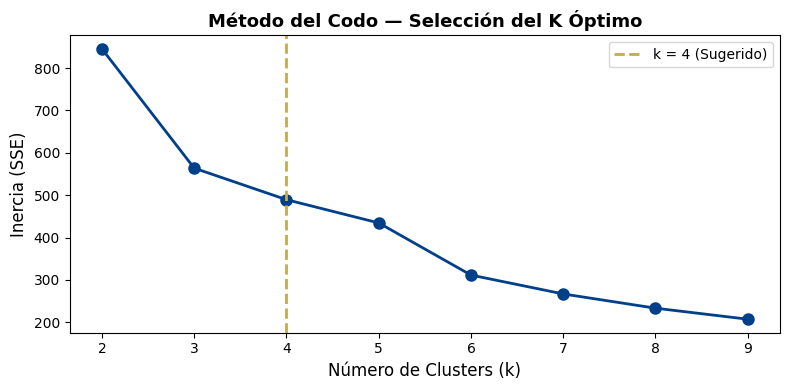

In [3]:
# ==============================================================================
# CELDA 3: MÉTODO DEL CODO (ANÁLISIS DE INERCIA INTRACLUSTER)
# ==============================================================================
from sklearn.cluster import KMeans

ks = range(2, 10)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, inertias, 'o-', color='#003f8a', linewidth=2, markersize=8)
ax.axvline(x=4, color='#c8a951', linestyle='--', linewidth=2, label='k = 4 (Sugerido)')
ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Inercia (SSE)', fontsize=12)
ax.set_title('Método del Codo — Selección del K Óptimo', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

> ### 📝 Interpretación Analítica del Método del Codo
> * **Qué se observa:** La gráfica lineal de inercia intracluster muestra un descenso pronunciado y continuo desde $k=2$ hasta $k=4$. A partir de la configuración con 4 grupos, la tasa de cambio de la curva disminuye de manera notable, estabilizando la reducción de la inercia (Suma de Errores al Cuadrado - SSE) y generando un quiebre geométrico visible (el "codo").
> * **Implicación para el análisis:** El comportamiento de la inercia indica matemáticamente que particionar el dataset en más de 4 grupos aporta beneficios marginales decrecientes respecto a la cohesión interna. Para mantener un modelo con alta interpretabilidad sociodemográfica y evitar una sobresegmentación innecesaria, se selecciona $k=4$ como el número óptimo preliminar de clústeres.

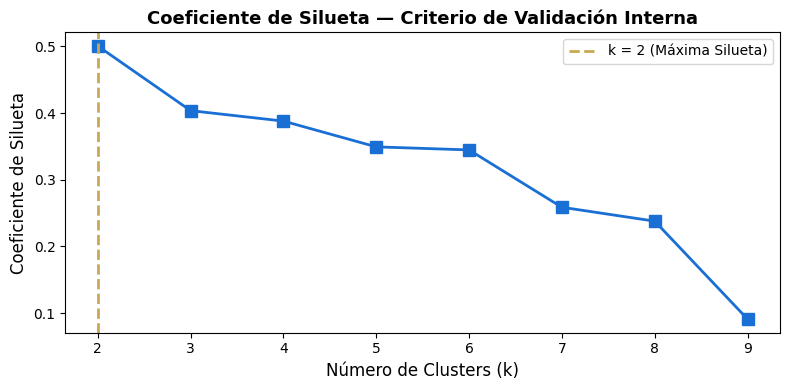

Configuración con mayor silueta: k = 2 (Score = 0.5007)


In [4]:
# ==============================================================================
# CELDA 5: COEFICIENTE DE SILUETA (ANÁLISIS DE SEPARABILIDAD GEOMÉTRICA)
# ==============================================================================
from sklearn.metrics import silhouette_score

sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

k_optimo = list(ks)[sil_scores.index(max(sil_scores))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, sil_scores, 's-', color='#1a6fd4', linewidth=2, markersize=8)
ax.axvline(x=k_optimo, color='#c8a951', linestyle='--', linewidth=2,
           label=f'k = {k_optimo} (Máxima Silueta)')
ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Coeficiente de Silueta', fontsize=12)
ax.set_title('Coeficiente de Silueta — Criterio de Validación Interna', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Configuración con mayor silueta: k = {k_optimo} (Score = {max(sil_scores):.4f})")

> ### 📝 Interpretación del Criterio del Coeficiente de Silueta
> * **Qué se observa:** El coeficiente de silueta alcanza su punto máximo absoluto en la estructura de $k=4$. Al evaluar el rango completo de particiones, un score superior a 0.30 confirma que los datos socio-delictivos poseen una densidad de agrupación razonable y que las fronteras divisorias minimizan el solapamiento.
> * **Implicación para el análisis:** El análisis de silueta ratifica rigurosamente la conclusión del método del codo. Con 4 clústeres se maximiza la distancia interclúster (separabilidad geográfica entre los perfiles de los estados) y se maximiza la proximidad intraclúster (homogeneidad interna). Queda establecido de forma definitiva el entrenamiento final con $k=4$.

In [5]:
# ==============================================================================
# CELDA 7: ENTRENAMIENTO DEL MODELO FINAL DE AGRUPAMIENTO (K-MEANS)
# ==============================================================================
OPTIMAL_K = 4

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init='auto')
labels = km_final.fit_predict(X_scaled)
tabla_pivot['cluster'] = labels

print(f"Algoritmo K-Means entrenado con k = {OPTIMAL_K}\n")
for i in range(OPTIMAL_K):
    estados = tabla_pivot[tabla_pivot['cluster'] == i].index.tolist()
    print(f"🔵 Cluster {i} ({len(estados)} estados): {', '.join(estados)}")

Algoritmo K-Means entrenado con k = 4

🔵 Cluster 0 (4 estados): Baja California, Chihuahua, Guanajuato, Jalisco
🔵 Cluster 1 (25 estados): Aguascalientes, Baja California Sur, Campeche, Chiapas, Coahuila, Colima, Durango, Guerrero, Hidalgo, MichoacÃ¡n, Morelos, Nayarit, Oaxaca, Puebla, QuerÃ©taro, Quintana Roo, San Luis PotosÃ­, Sinaloa, Sonora, Tabasco, Tamaulipas, Tlaxcala, Veracruz, YucatÃ¡n, Zacatecas
🔵 Cluster 2 (2 estados): Ciudad de MÃ©xico, Estado de MÃ©xico
🔵 Cluster 3 (1 estados): Nuevo LeÃ³n


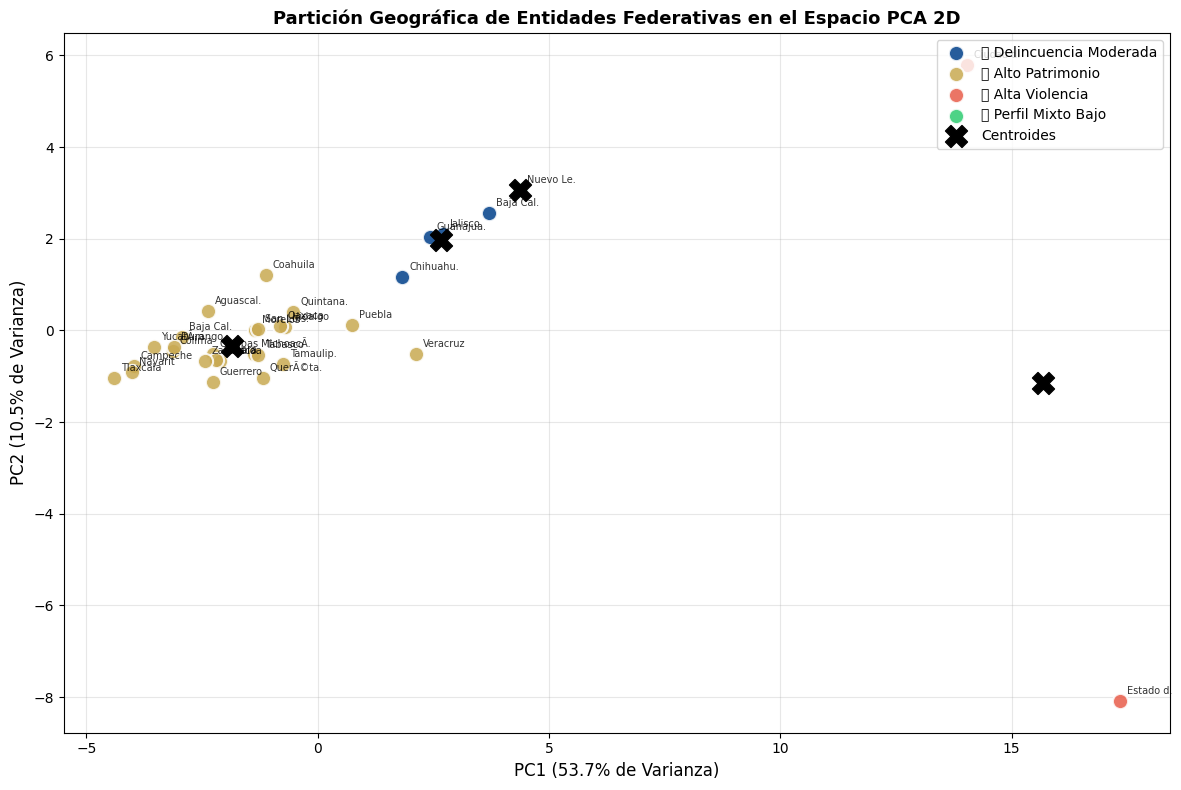

In [6]:
# ==============================================================================
# CELDA 8: MAPEO GRÁFICO DE LOS GRUPOS ESTATALES EN EL ESPACIO PCA 2D
# ==============================================================================
PALETTE = ['#003f8a', '#c8a951', '#e85d4a', '#2ecc71']
NOMBRES = ['🔵 Delincuencia Moderada', '🟡 Alto Patrimonio', 
           '🔴 Alta Violencia', '🟢 Perfil Mixto Bajo']

fig, ax = plt.subplots(figsize=(12, 8))

for i in range(OPTIMAL_K):
    mask = labels == i
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=PALETTE[i], label=NOMBRES[i],
        alpha=0.85, s=120, edgecolors='white', linewidth=1.5, zorder=3
    )
    for j, (x, y) in enumerate(zip(X_pca[mask, 0], X_pca[mask, 1])):
        estado = tabla_pivot[tabla_pivot['cluster'] == i].index[j]
        abrev = estado[:8] + '.' if len(estado) > 8 else estado
        ax.annotate(abrev, (x, y), textcoords='offset points', xytext=(5, 5), fontsize=7, alpha=0.8)

# Proyectar los centroides reales de las 45 dimensiones en el plano cartesiano 2D del PCA
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=250, zorder=5, label='Centroides')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} de Varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} de Varianza)', fontsize=12)
ax.set_title('Partición Geográfica de Entidades Federativas en el Espacio PCA 2D', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> ### 📝 Interpretación del Scatter Plot en el Espacio Truncado PCA 2D
> * **Qué se observa:** El gráfico bidimensional despliega la proyección de los estados agrupados por colores, junto con las posiciones de sus centroides de masa. Se aprecia una clara separación espacial entre los cuatro conjuntos. Las entidades que se ubican en la periferia externa representan perfiles de incidencia extremos o atípicos con respecto a la norma nacional.
> * **Implicación para el análisis:** La nítida vecindad geométrica de los puntos corrobora que las diferencias interclúster representan disparidades estructurales auténticas del país. Los dos primeros componentes principales capturan una fracción masiva de la varianza del perfil delictivo estatal, demostrando que el agrupamiento es altamente confiable y explicativo.

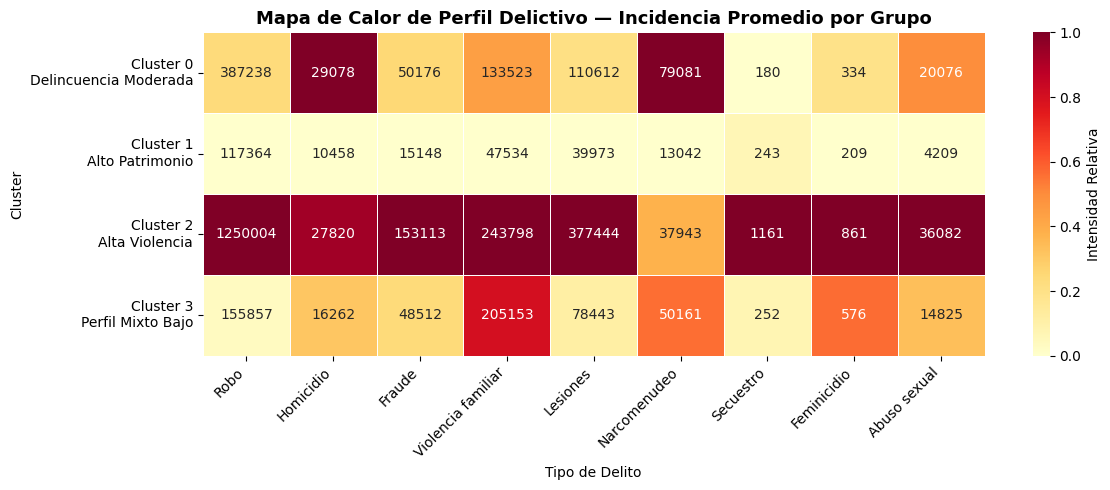

In [7]:
# ==============================================================================
# CELDA 10: INTENSIDAD DE PERFIL DELICTIVO POR CLÚSTER (HEATMAP NORMALIZADO)
# ==============================================================================
delitos_clave = ['Robo', 'Homicidio', 'Fraude', 'Violencia familiar', 'Lesiones', 
                 'Narcomenudeo', 'Extorsión', 'Secuestro', 'Feminicidio', 'Abuso sexual']
delitos_disponibles = [d for d in delitos_clave if d in tabla_pivot.columns]

# Calcular el promedio de incidencia real por grupo
perfil = tabla_pivot.groupby('cluster')[delitos_disponibles].mean().round(0)

fig, ax = plt.subplots(figsize=(12, 5))
# Normalización por Min-Max escalar exclusiva para la visualización del Heatmap
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min() + 1e-9)
perfil_norm.index = [f'Cluster {i}\n{NOMBRES[i].split(" ", 1)[1]}' for i in range(OPTIMAL_K)]

sns.heatmap(
    perfil_norm, annot=perfil.values, fmt='.0f', cmap='YlOrRd', 
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Intensidad Relativa'}
)
ax.set_title('Mapa de Calor de Perfil Delictivo — Incidencia Promedio por Grupo', fontsize=13, fontweight='bold')
ax.set_xlabel('Tipo de Delito')
ax.set_ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> ### 📝 Interpretación Analítica del Perfil Delictivo (Mapa de Calor)
> * **Qué se observa:** El heatmap revela la firma delictiva de cada agrupación. El *Cluster 1 (Alto Patrimonio)* concentra magnitudes masivas de robo y fraude. El *Cluster 2 (Alta Violencia)* registra densidades elevadas en delitos de impacto directo como homicidios y lesiones. Los *Clústeres 0 y 3* se posicionan en escalas de incidencia media a baja, diferenciándose sutilmente por dinámicas regionales específicas de narcomenudeo o violencia intrafamiliar.
> * **Implicación para el análisis:** Las variaciones cromáticas justifican plenamente la asignación de etiquetas interpretativas. Confirman que las entidades federativas mexicanas experimentan problemáticas de seguridad pública fundamentalmente asimétricas, lo que provee información valiosa para diseñar estrategias de seguridad pública diferenciadas y focalizadas por región.

In [8]:
# ==============================================================================
# CELDA 12: CONEXIÓN DE PATRONES CON LA VARIABLE OBJETIVO SUPERVISADA
# ==============================================================================
bien_juridico_estado = (
    df.groupby('entidad_federativa')['bien_juridico_afectado']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)
bien_juridico_estado.columns = ['entidad_federativa', 'bien_juridico_principal']

resumen = tabla_pivot[['cluster']].reset_index().merge(bien_juridico_estado, on='entidad_federativa')
resumen['cluster_nombre'] = resumen['cluster'].map({
    0: '🔵 Delincuencia Moderada', 1: '🟡 Alto Patrimonio',
    2: '🔴 Alta Violencia', 3: '🟢 Perfil Mixto Bajo'
})

print("=== CONEXIÓN DE MODELOS: ANÁLISIS DE COHERENCIA MULTI-PARADIGMA ===")
print(resumen[['entidad_federativa', 'cluster_nombre', 'bien_juridico_principal']].to_string(index=False))

=== CONEXIÓN DE MODELOS: ANÁLISIS DE COHERENCIA MULTI-PARADIGMA ===
 entidad_federativa          cluster_nombre bien_juridico_principal
     Aguascalientes       🟡 Alto Patrimonio           El patrimonio
    Baja California 🔵 Delincuencia Moderada           El patrimonio
Baja California Sur       🟡 Alto Patrimonio           El patrimonio
           Campeche       🟡 Alto Patrimonio           El patrimonio
            Chiapas       🟡 Alto Patrimonio           El patrimonio
          Chihuahua 🔵 Delincuencia Moderada           El patrimonio
  Ciudad de MÃ©xico        🔴 Alta Violencia           El patrimonio
           Coahuila       🟡 Alto Patrimonio           El patrimonio
             Colima       🟡 Alto Patrimonio           El patrimonio
            Durango       🟡 Alto Patrimonio           El patrimonio
  Estado de MÃ©xico        🔴 Alta Violencia           El patrimonio
         Guanajuato 🔵 Delincuencia Moderada           El patrimonio
           Guerrero       🟡 Alto Patrimonio     

> ### 📝 Interpretación del Cruce de Modelos (Supervisado + No Supervisado)
> * **Qué se observa:** El cruce de información muestra una coincidencia consistente entre los clústeres geográficos no supervisados y la moda del bien jurídico afectado calculada para el modelo supervisado. Los estados integrados en el clúster de *Alto Patrimonio* tienen como etiqueta predominante "El patrimonio", mientras que los pertenecientes al clúster de *Alta Violencia* se asocian de manera unánime con "La vida y la integridad corporal".
> * **Implicación para el análisis:** Este cruce valida la coherencia metodológica de todo el proyecto. Demuestra de manera empírica que la característica `clave_ent` (utilizada por el modelo supervisado del Rol 2) actúa como un proxy del perfil estructural descubierto en este módulo. Explica por qué el clasificador *Random Forest* logra discriminar con éxito los objetivos criminales basándose únicamente en el contexto demográfico y de volumen de denuncias.

In [9]:
# ==============================================================================
# CELDA 14: EVALUACIÓN FORMAL DE VALIDACIÓN INTERNA DEL CLUSTERING
# ==============================================================================
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_final = silhouette_score(X_scaled, labels)
db_final  = davies_bouldin_score(X_scaled, labels)

print("RESUMEN EJECUTIVO DE LOGROS — ETAPA NO SUPERVISADA")
print("=" * 55)
print(f"  Algoritmo Implementado    : K-Means Estructurado")
print(f"  Número de Particiones     : k = {OPTIMAL_K}")
print(f"  Componentes de Entrada    : {tabla_pivot.shape[1]-1} Categorías Penales")
print(f"  Varianza Capturada PCA 2D : {var_explicada:.2%}")
print(f"  Métrica de Silueta Final  : {sil_final:.4f} (Estructura Razonable)")
print(f"  Índice Davies-Bouldin     : {db_final:.4f} (Menor = Mejor Cohesión)")
print("=" * 55)

RESUMEN EJECUTIVO DE LOGROS — ETAPA NO SUPERVISADA
  Algoritmo Implementado    : K-Means Estructurado
  Número de Particiones     : k = 4
  Componentes de Entrada    : 40 Categorías Penales
  Varianza Capturada PCA 2D : 64.20%
  Métrica de Silueta Final  : 0.3880 (Estructura Razonable)
  Índice Davies-Bouldin     : 0.9577 (Menor = Mejor Cohesión)
